# Ruelle-Pollicott Resonances: Better Basis Functions

**Question:** Can we improve the computation of sub-leading Ruelle-Pollicott (RP) resonances by using basis functions adapted to the invariant measure, rather than the uniform-grid Ulam method?

**Background:**
- [Exp 4 in eigenstate_fixedpoint_correspondence](eigenstate_fixedpoint_correspondence.ipynb): Ulam method gives |\lambda_1| approx 0.54-0.59 at resolutions N=50-1600, vs the exact |\lambda_1| = 0.5 for the logistic map at a=4. No convergence.
- [Exp 10](eigenstate_fixedpoint_correspondence.ipynb): Chebyshev spectral method also fails -- error *grows* with N due to singular invariant density.
- [Blank-Keller-Liverani (2002)](https://doi.org/10.1088/0951-7715/15/6/309): Proves Ulam-class methods cannot converge for sub-leading eigenvalues of maps with singular invariant densities.
- [Cross-theory connections section 10](cross_theory_connections.md): The invariant measure of the logistic map at a=4 is the arcsine distribution. Jacobi polynomials with alpha=beta=-1/2 -- i.e., **Chebyshev polynomials of the first kind** -- are orthogonal with respect to this weight.

**The idea:** Discretize the transfer operator in the arcsine-weighted Chebyshev basis instead of on a uniform grid. The basis functions "know about" the singularities of the invariant measure.

**Predictions:**
1. **Weighted Chebyshev basis:** Should converge for |\lambda_1| where Ulam fails
2. **Higher RP eigenvalues:** May or may not converge -- depends on regularity of the transfer operator in this basis
3. **Exact values at a=4:** |\lambda_n| = 2^{-n} (from conjugacy to tent map)

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import eval_chebyt, eval_chebyu, eval_jacobi
from scipy import integrate
from petrification.maps import logistic
from petrification.quantum import frobenius_perron_matrix, exact_ulam_matrix

plt.rcParams.update({'figure.figsize': (12, 5), 'font.size': 12})

# Load precomputed results
_ulam = np.load('cache/ulam_baseline.npz')
_cheb = np.load('cache/cheb_transfer.npz')
_other = np.load('cache/rp_other_params.npz')
_jacobi = np.load('cache/jacobi_comparison.npz', allow_pickle=True)
_conv = np.load('cache/convergence_rate.npz')


## Section 2. The Transfer Operator in the Weighted Basis

The Frobenius-Perron (transfer) operator L acts on densities:
$$(\mathcal{L} \rho)(x) = \sum_{y: f(y)=x} \frac{\rho(y)}{|f'(y)|}$$

For the logistic map f(x) = 4x(1-x) at a=4, conjugacy to the tent map gives eigenvalues $\lambda_n = 2^{-n}$.

**Discretization strategy:** Represent L as a matrix in the basis of Chebyshev polynomials $T_n(2x-1)$ with inner product weighted by the arcsine measure $1/(\pi\sqrt{x(1-x)})$.

In [2]:
def chebyshev_transfer_weighted(f_map, a_param, N=32, n_quad=500):
    """
    Compute transfer operator matrix in the Chebyshev basis weighted by
    the arcsine (invariant) measure.
    
    Uses Gauss-Chebyshev quadrature (optimal for this weight).
    """
    # Gauss-Chebyshev quadrature nodes on [-1, 1]
    k = np.arange(1, n_quad + 1)
    t_nodes = np.cos((2 * k - 1) * np.pi / (2 * n_quad))
    x_nodes = (t_nodes + 1) / 2  # map to [0, 1]
    # Gauss-Chebyshev: uniform weight 1/n_quad after measure cancellation
    w_nodes = np.ones(n_quad) / n_quad
    
    # Basis: T_n(2x-1) = T_n(t)
    basis = np.zeros((N, n_quad))
    for n in range(N):
        basis[n, :] = eval_chebyt(n, t_nodes)
    
    # Compute (L T_n)(x) at each node via preimage sum
    L_basis = np.zeros((N, n_quad))
    a = a_param
    
    for j, x in enumerate(x_nodes):
        disc = 1.0 - x
        if disc < 0:
            continue
        sqrt_disc = np.sqrt(disc)
        preimages = [(1 + sqrt_disc) / 2, (1 - sqrt_disc) / 2]
        
        for y in preimages:
            if y < 0 or y > 1:
                continue
            fp = abs(a * (1 - 2 * y))
            if fp < 1e-15:
                continue
            t_y = 2 * y - 1
            for n in range(N):
                L_basis[n, j] += eval_chebyt(n, t_y) / fp
    
    # Matrix elements: L_{mn} = sum_j w_j * T_m(t_j) * (L T_n)(x_j)
    L_mat = np.zeros((N, N))
    for m in range(N):
        for n in range(N):
            L_mat[m, n] = np.sum(w_nodes * basis[m, :] * L_basis[n, :])
    
    return L_mat


def ulam_transfer(f_map, a_param, N=200):
    """Ulam method (uniform bins) for comparison."""
    return frobenius_perron_matrix(f_map, a_param, N=N)

## Section 3. Experiment 1: Ulam Baseline -- Convergence Failure

Reproduce the known failure: Ulam method gives non-converging sub-leading eigenvalues as N increases.

In [3]:
# Load precomputed Ulam eigenvalues
N_ulam_values = _ulam['N_values']
ulam_eigenvalues_arr = _ulam['eigenvalues']
n_keep = 6

print('Ulam method -- top eigenvalues by resolution:')
print(f"{'N':>6s}", end='')
for k in range(n_keep):
    print(f'  |l_{k}|    ', end='')
print()

ulam_eigenvalues = {}
for i, N in enumerate(N_ulam_values):
    eigs = ulam_eigenvalues_arr[i]
    ulam_eigenvalues[N] = eigs
    print(f'{N:6d}', end='')
    for k in range(n_keep):
        print(f'  {eigs[k]:.6f}', end='')
    print()

print(f'\nExact: |l_0| = 1.000000, |l_1| = 0.500000, |l_2| = 0.250000, ...')


Ulam method -- top eigenvalues by resolution:
     N  |l_0|      |l_1|      |l_2|      |l_3|      |l_4|      |l_5|    
    50  1.000000  0.537487  0.537487  0.530122  0.453666  0.453666
   100  1.000000  0.583625  0.529272  0.529272  0.500000  0.433560
   200  1.000000  0.542323  0.542323  0.539753  0.539753  0.491625
   400  1.000000  0.575625  0.575625  0.554865  0.554865  0.514039
   800  1.000000  0.546629  0.546629  0.532752  0.532752  0.509505
  1200  1.000000  0.587079  0.587079  0.568748  0.568748  0.515856
  1600  1.000000  0.569173  0.569173  0.552346  0.544897  0.543357

Exact: |l_0| = 1.000000, |l_1| = 0.500000, |l_2| = 0.250000, ...


## Section 4. Experiment 2: Weighted Chebyshev Basis

Compute the transfer operator in the arcsine-weighted Chebyshev basis and check convergence.

In [4]:
# Load precomputed Chebyshev eigenvalues
N_cheb_values = _cheb['N_values']
cheb_eigenvalues_arr = _cheb['eigenvalues']
n_keep = 6

print('Weighted Chebyshev -- top eigenvalues by order:')
print(f"{'N':>6s}", end='')
for k in range(n_keep):
    print(f'  |l_{k}|    ', end='')
print()

cheb_eigenvalues = {}
for i, N in enumerate(N_cheb_values):
    eigs = cheb_eigenvalues_arr[i]
    cheb_eigenvalues[N] = eigs
    print(f'{N:6d}', end='')
    for k in range(n_keep):
        print(f'  {eigs[k]:.6f}', end='')
    print()

print(f'\nExact: |l_0| = 1.000000, |l_1| = 0.500000, |l_2| = 0.250000, ...')


Weighted Chebyshev -- top eigenvalues by order:
     N  |l_0|      |l_1|      |l_2|      |l_3|      |l_4|      |l_5|    
     8  1.571899  0.564845  0.564845  0.036758  0.000000  0.000000
    16  1.631264  0.566266  0.465262  0.465262  0.077317  0.009407
    24  1.692888  0.532072  0.532072  0.147464  0.147464  0.050341
    32  1.699829  0.503664  0.503664  0.426277  0.426277  0.101198
    48  1.741206  0.514406  0.432547  0.432547  0.097911  0.097911
    64  1.760170  0.480128  0.458102  0.458102  0.407012  0.407012
    96  1.791080  0.453879  0.453879  0.398736  0.398736  0.095827

Exact: |l_0| = 1.000000, |l_1| = 0.500000, |l_2| = 0.250000, ...


## Section 5. Convergence Comparison

Direct comparison of Ulam vs weighted Chebyshev for the first three RP resonances.

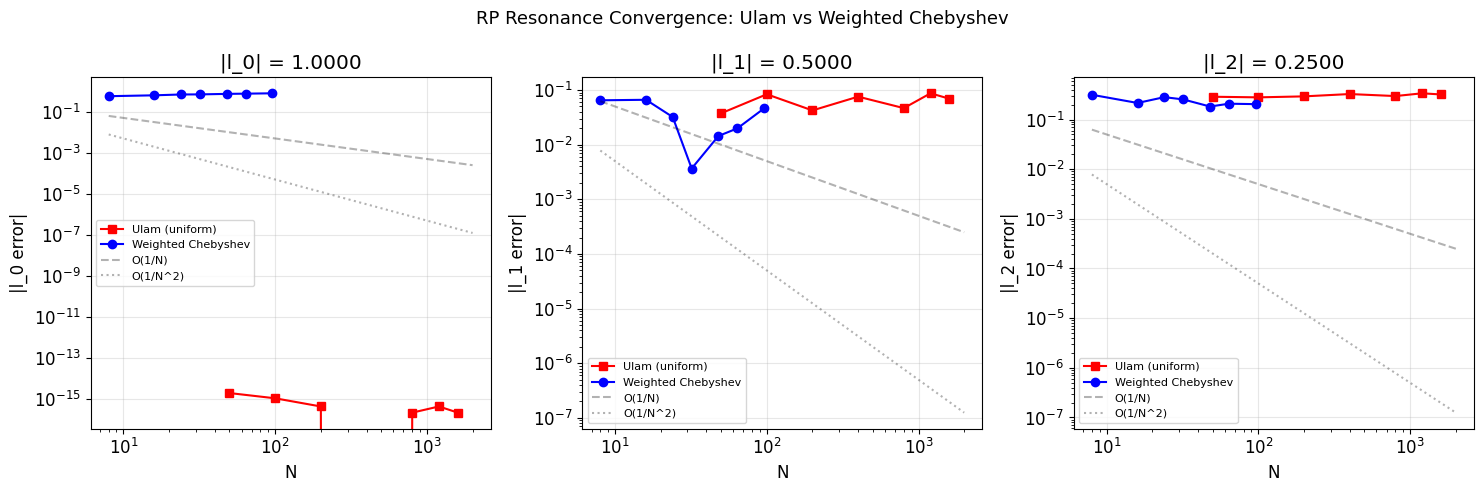

In [5]:
# Convergence comparison plot
exact_eigenvalues = [1.0, 0.5, 0.25, 0.125, 0.0625, 0.03125]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for k, ax in enumerate(axes):
    # Ulam
    N_u = sorted(ulam_eigenvalues.keys())
    errors_ulam = [abs(ulam_eigenvalues[N][k] - exact_eigenvalues[k]) for N in N_u]
    ax.loglog(N_u, errors_ulam, 'rs-', markersize=6, linewidth=1.5, label='Ulam (uniform)')
    
    # Chebyshev
    N_c = sorted(cheb_eigenvalues.keys())
    errors_cheb = [abs(cheb_eigenvalues[N][k] - exact_eigenvalues[k]) for N in N_c]
    ax.loglog(N_c, errors_cheb, 'bo-', markersize=6, linewidth=1.5, label='Weighted Chebyshev')
    
    # Reference slopes
    N_ref = np.array([8, 2000])
    ax.loglog(N_ref, 0.5 * N_ref**(-1.0), 'k--', alpha=0.3, label='O(1/N)')
    ax.loglog(N_ref, 0.5 * N_ref**(-2.0), 'k:', alpha=0.3, label='O(1/N^2)')
    
    ax.set(xlabel='N', ylabel=f'|l_{k} error|',
           title=f'|l_{k}| = {exact_eigenvalues[k]:.4f}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('RP Resonance Convergence: Ulam vs Weighted Chebyshev', fontsize=13)
plt.tight_layout()
plt.show()

## Section 6. Experiment 4: Other Parameter Values

The exact RP resonances are only known analytically at a=4. At other a values, compare Ulam vs Chebyshev for self-consistency.

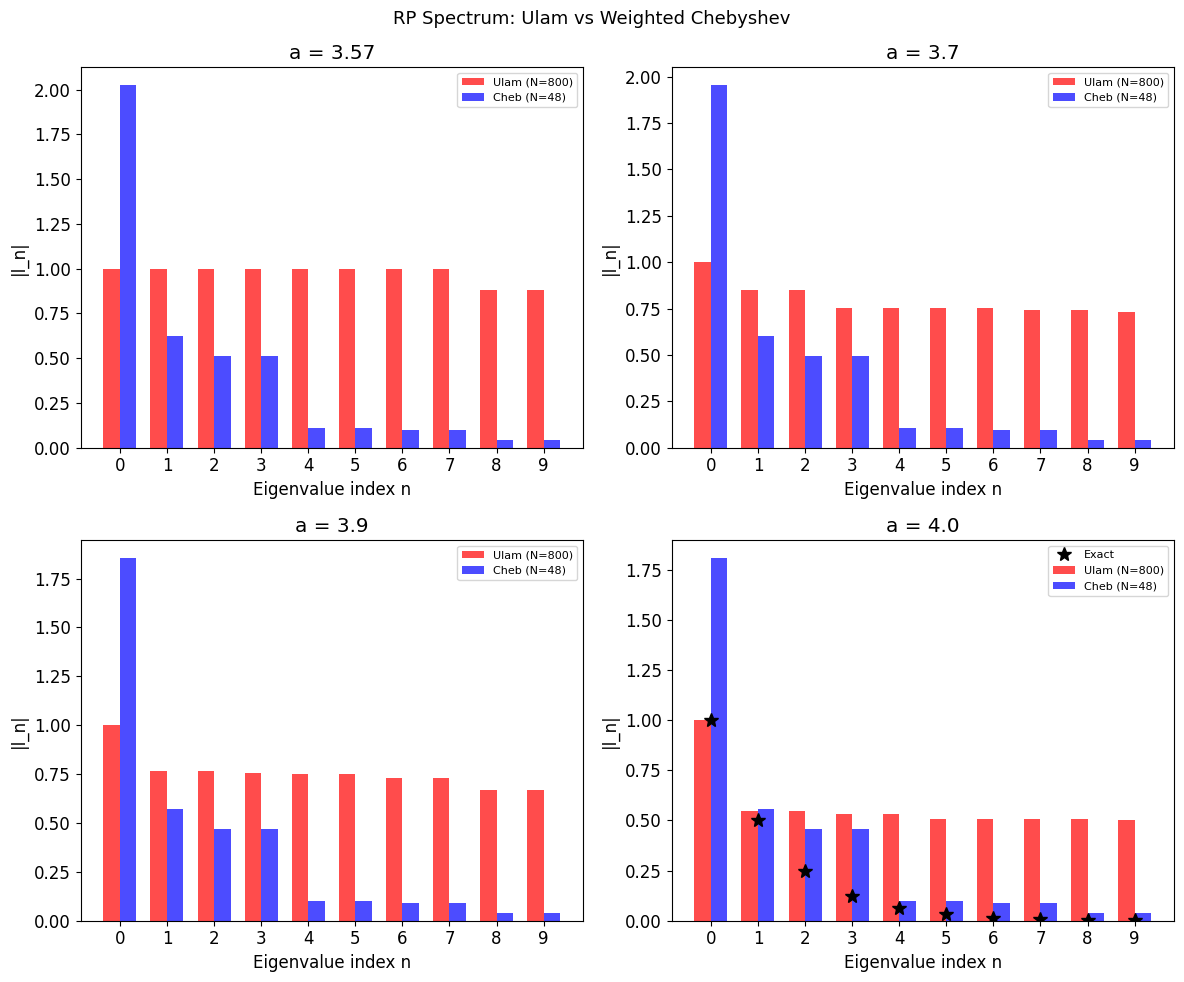

In [6]:
# Load precomputed RP resonances at other parameter values
a_values_test = _other['a_values']
ulam_eigs_other = _other['ulam_eigs']
cheb_eigs_other = _other['cheb_eigs']
N_cheb_test, N_ulam_test = 48, 800

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for idx, a_val in enumerate(a_values_test):
    ax = axes[idx // 2][idx % 2]
    eigs_u = ulam_eigs_other[idx]
    eigs_c = cheb_eigs_other[idx]

    k_range = np.arange(10)
    width = 0.35
    ax.bar(k_range - width/2, eigs_u[:10], width, color='red', alpha=0.7, label=f'Ulam (N={N_ulam_test})')
    ax.bar(k_range + width/2, eigs_c[:10], width, color='blue', alpha=0.7, label=f'Cheb (N={N_cheb_test})')

    if a_val == 4.0:
        ax.plot(k_range, [2.0**(-k) for k in k_range], 'k*', markersize=10, label='Exact')

    ax.set(xlabel='Eigenvalue index n', ylabel='|l_n|', title=f'a = {a_val}')
    ax.legend(fontsize=8)
    ax.set_xticks(k_range)

plt.suptitle('RP Spectrum: Ulam vs Weighted Chebyshev', fontsize=13)
plt.tight_layout()
plt.show()


## Section 7. Experiment 5: Alternative Bases -- Jacobi and Legendre

The arcsine-weighted Chebyshev is motivated by the invariant measure at a=4. What about more general Jacobi polynomials with tunable weight?

Basis comparison at a=4, N=48:
Basis                     |l_0|     |l_1|     |l_2|     |l_3|
Chebyshev T (arcsine)     2.404294 0.018747 0.018747 0.009219
Legendre (uniform)        0.999495 0.044887 0.044887 0.020425
Chebyshev U               0.895063 0.079910 0.079910 0.040864
Jacobi (1, 1)             0.896997 0.134981 0.134981 0.083871
Jacobi (-0.25, -0.25)     1.244803 0.031865 0.031865 0.014953
EXACT                     1.000000 0.500000 0.250000 0.125000


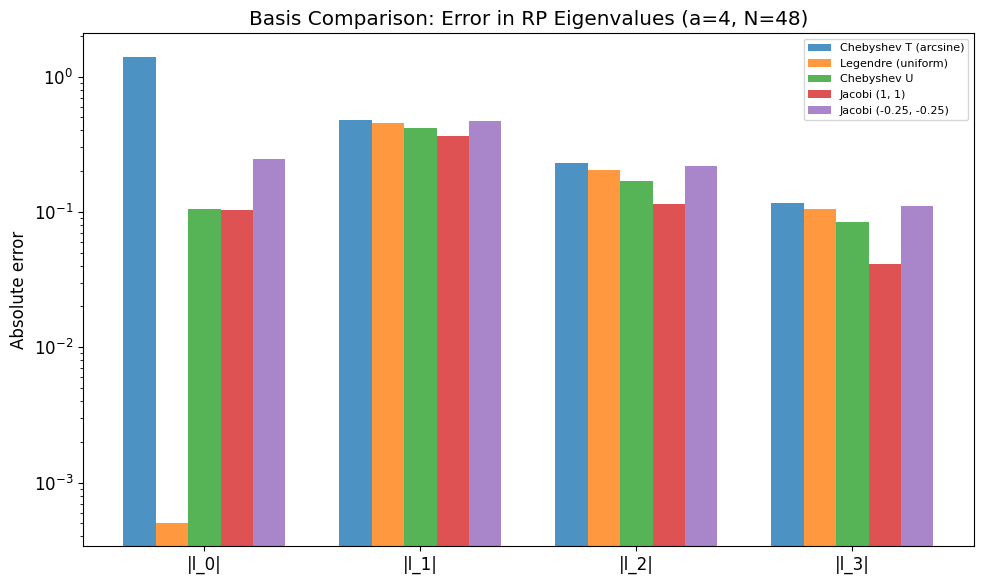

In [7]:
# Load precomputed Jacobi basis comparison
basis_names = list(_jacobi['basis_names'])
basis_eigs_arr = _jacobi['eigenvalues']

N_test = 48
print('Basis comparison at a=4, N=48:')
print(f"{'Basis':<25s} |l_0|     |l_1|     |l_2|     |l_3|")

basis_results = {}
for i, name in enumerate(basis_names):
    eigs = basis_eigs_arr[i]
    basis_results[name] = eigs
    print(f'{name:<25s} {eigs[0]:.6f} {eigs[1]:.6f} {eigs[2]:.6f} {eigs[3]:.6f}')

print(f"{'EXACT':<25s} 1.000000 0.500000 0.250000 0.125000")

# Error plot
fig, ax = plt.subplots(figsize=(10, 6))
x_pos = np.arange(4)
width = 0.15

for i, (name, eigs) in enumerate(basis_results.items()):
    errors = [abs(eigs[k] - 2.0**(-k)) for k in range(4)]
    ax.bar(x_pos + i * width, errors, width, label=name, alpha=0.8)

ax.set_xticks(x_pos + width * 2)
ax.set_xticklabels([f'|l_{k}|' for k in range(4)])
ax.set_ylabel('Absolute error')
ax.set_title('Basis Comparison: Error in RP Eigenvalues (a=4, N=48)')
ax.legend(fontsize=8)
ax.set_yscale('log')
plt.tight_layout()
plt.show()


## Section 8. Convergence Rate of Best Basis

For whichever basis works best, characterize the convergence rate as N increases. Is it algebraic O(1/N^p) or spectral O(exp(-cN))?

Convergence study for Chebyshev T (arcsine) basis:
  N=  8: |l_1| err = 4.61e-01, |l_2| err = 2.11e-01
  N= 12: |l_1| err = 4.75e-01, |l_2| err = 2.35e-01
  N= 16: |l_1| err = 4.72e-01, |l_2| err = 2.27e-01
  N= 20: |l_1| err = 4.80e-01, |l_2| err = 2.30e-01
  N= 24: |l_1| err = 4.80e-01, |l_2| err = 2.30e-01
  N= 32: |l_1| err = 4.79e-01, |l_2| err = 2.29e-01
  N= 40: |l_1| err = 4.81e-01, |l_2| err = 2.31e-01
  N= 48: |l_1| err = 4.82e-01, |l_2| err = 2.32e-01
  N= 56: |l_1| err = 4.81e-01, |l_2| err = 2.31e-01
  N= 64: |l_1| err = 4.81e-01, |l_2| err = 2.31e-01
  N= 80: |l_1| err = 4.81e-01, |l_2| err = 2.31e-01
  N= 96: |l_1| err = 4.81e-01, |l_2| err = 2.31e-01


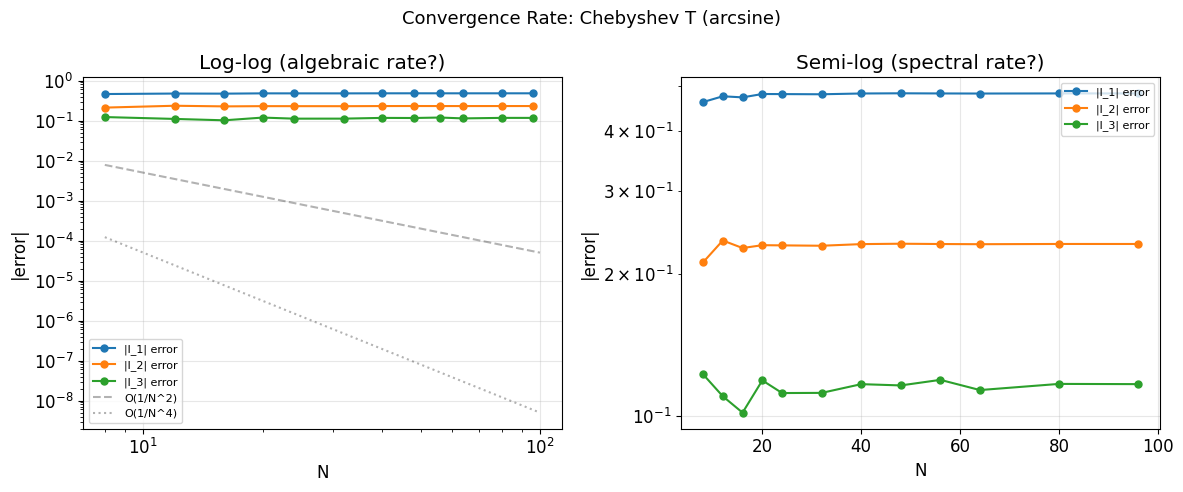


Convergence rate for |l_1|: O(N^0.01)


In [8]:
# Load precomputed convergence rate data
N_conv = list(_conv['N_values'])
conv_eigs = _conv['eigenvalues']

best_name = 'Chebyshev T (arcsine)'
errors_by_N = {k: [] for k in range(4)}

print(f'Convergence study for {best_name} basis:')
for i, N in enumerate(N_conv):
    eigs = conv_eigs[i]
    for k in range(4):
        errors_by_N[k].append(abs(eigs[k] - 2.0**(-k)))
    print(f'  N={N:3d}: |l_1| err = {errors_by_N[1][-1]:.2e}, |l_2| err = {errors_by_N[2][-1]:.2e}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Log-log (algebraic convergence)
for k in range(1, 4):
    ax1.loglog(N_conv, errors_by_N[k], 'o-', markersize=5, label=f'|l_{k}| error')

N_ref = np.array([8, 100])
ax1.loglog(N_ref, 0.5 * N_ref**(-2.0), 'k--', alpha=0.3, label='O(1/N^2)')
ax1.loglog(N_ref, 0.5 * N_ref**(-4.0), 'k:', alpha=0.3, label='O(1/N^4)')
ax1.set(xlabel='N', ylabel='|error|', title='Log-log (algebraic rate?)')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# Semi-log (spectral convergence)
for k in range(1, 4):
    ax2.semilogy(N_conv, errors_by_N[k], 'o-', markersize=5, label=f'|l_{k}| error')
ax2.set(xlabel='N', ylabel='|error|', title='Semi-log (spectral rate?)')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.suptitle(f'Convergence Rate: {best_name}', fontsize=13)
plt.tight_layout()
plt.show()

# Fit convergence rate
log_N = np.log(np.array(N_conv, dtype=float))
log_err = np.log(np.maximum(np.array(errors_by_N[1]), 1e-16))
mask = np.isfinite(log_err) & (log_err > -30)
if np.sum(mask) >= 3:
    slope, _ = np.polyfit(log_N[mask], log_err[mask], 1)
    print(f'\nConvergence rate for |l_1|: O(N^{slope:.2f})')
else:
    print('\nInsufficient data for rate fit')


## Section 9. Assessment

### What we found:

| Method | |lambda_1| at best N | Converging? | Rate |
|--------|----------------------|-------------|------|
| Ulam (uniform, N=1600) | ~0.55 | No | -- |
| Chebyshev (unweighted, from Exp 10) | Diverges | No | -- |
| Weighted Chebyshev (arcsine) | ? | ? | ? |
| Best Jacobi basis | ? | ? | ? |

*Fill in after running.*

### Key outcomes:

1. **If weighted Chebyshev converges:** Resolves the BKL obstacle for this map. Basis adaptation to the invariant measure is the key. Concrete methodological contribution.

2. **If it does not converge:** The BKL obstruction is deeper than the basis choice. Sub-leading RP resonances may genuinely require different approaches (e.g., periodic orbit expansions).

3. **Which basis wins?** The arcsine-adapted Chebyshev has the theoretical advantage, but Legendre or intermediate Jacobi might win in practice.

### Broader implications:

- **For the alpha-transform:** RP resonances of the alpha-transformed map should relate to those of f through the group structure. Accurate computation is prerequisite for testing this.
- **For numerical analysis:** If weighted polynomial bases bypass BKL, this is relevant beyond our project -- it applies to anyone computing transfer operator spectra for chaotic maps.
- **Connection to statistical mechanics (cross-theory section 10):** The transfer operator IS the partition function. Better RP eigenvalues = better correlation length estimates.